# From galaxy colours to spectroscopic redshift

## The scientific problem

Astronomical surveys obtain two complementary types of observations:

- **Imaging:** an object is observed through a small number of broad wavelength filters.
- **Spectroscopy:** the object's light is separated into many narrow wavelength bins, producing a spectrum as introduced in Lecture 1.

Spectroscopy contains much more detailed wavelength information, so it usually provides a much more precise redshift measurement. However, obtaining spectra for every detected galaxy is expensive, while imaging can be collected for many more objects.

In this exercise, we use galaxies for which both imaging and spectroscopy are available. The spectroscopic redshift, `z_spec`, is used as the target that teaches the model how redshift is encoded in photometry.

Our aim is to learn $p(z_{\rm spec}\mid\mathbf{x}_{\rm phot}),$ where $\mathbf{x}_{\rm phot}$ contains measurements derived from galaxy photometric imaging. In other words, we want to train a network to predict the spectroscopic redshift that is expensive to obtain from photometric measurements that are much cheaper to obtain.

In this notebook, we have two baseline examples:
- Deterministic MLP: it just predicts one spectroscopic redshift estimate for a given input.
- MDN: a supervised conditional density estimator. Its forward pass deterministically predicts a Gaussian-mixture PDF, from which we can sample possible redshifts conditional on the photometry.

---

## What is in the catalogue?

A **magnitude** is a logarithmic measure of brightness: a **smaller magnitude means a brighter object**.

A **colour** is the difference between two magnitudes, for example $u-g = u_{\rm mag}-g_{\rm mag}$.

Colours therefore describe the broad shape of a galaxy's spectrum rather than its overall brightness.

| Column | Meaning | Possible use |
|---|---|---|
| `raw_u-g`, `raw_g-r`, `raw_r-i`, `raw_i-z` | Colours calculated directly from the measured SDSS model magnitudes | These are the starter inputs, but they have not been corrected for foreground Milky Way extinction |
| `u-g`, `g-r`, `r-i`, `i-z` | The same colours after correcting each magnitude for foreground extinction | Colours corrected for foreground Milky Way extinction |
| `r_mag` | Extinction-corrected apparent magnitude in the SDSS $r$ band | Adds the galaxy's overall apparent brightness, which is absent from colour differences |
| `concentration_r` | $R_{90}/R_{50}$, where $R_{50}$ and $R_{90}$ contain 50% and 90% of the galaxy's Petrosian $r$-band flux | A simple measure of how centrally concentrated the galaxy image is; it acts as a crude morphology feature |
| `z_spec` | Redshift $0.01 \lesssim z \lesssim 0.8$ measured from the galaxy spectrum | Supervised learning target |
| `source_id` | Unique row identifier | Used only to construct the Kaggle submission; never use it as a model input |
| `z_spec_err` | Reported uncertainty on `z_spec` | Optional extension discussed at the end of the notebook |

The starter model deliberately uses only the uncorrected colours:

```python
FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]
```
Possible improvements include replacing these inputs with extinction-corrected colours and adding `r_mag` and/or `concentration_r`.
There are also intentionally corrupted rows in the training data. The unchanged notebook produces a valid baseline submission, but inspecting and cleaning the data may improve your score.

## The Competition

- Each team may make at most **five** Kaggle submissions.
- Every submitted model must describe its prediction as a Gaussian mixture with **at most five components**. 
- The leaderboard uses the probability assigned to each hidden spectroscopic redshift, so **both** the predicted redshift **and** the predicted uncertainty matter.
- The hidden test targets are not corrupted. Models trained blindly on corrupted rows may generalise poorly, so careful inspection and cleaning can improve the leaderboard score.

In [1]:
from src import data, training, submission, models
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import functional as F

In [2]:
SEED = 42

AVAILABLE_FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
    "u-g",
    "g-r",
    "r-i",
    "i-z",
    "r_mag",
    "concentration_r",
]

# Deliberately basic starting point
FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]

HIDDEN_DIMS = [32]
DROPOUT = 0.0
LEARNING_RATE = 1.0e-3
N_COMPONENTS = 3
N_EPOCHS = 15       # maximum passes through the full training set
BATCH_SIZE = 1024   # galaxies used for one gradient update
PATIENCE = 4        # stop after this many epochs without improvement

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Load the data


In [3]:
train_df, valid_df, test_df = data.load_data(
    feature_columns=[
        "source_id",
        *AVAILABLE_FEATURES,
        "z_spec",
    ]
)

In [4]:
train_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r,z_spec
0,75721,0.44290,0.29774,0.29979,0.06408,0.384739,0.234483,0.263315,0.037050,18.369424,2.705443,0.148594
1,80184,5.02115,1.73387,0.62599,0.29016,5.003120,1.714261,0.614683,0.281781,19.030725,3.061816,0.370307
2,19864,2.28812,1.31279,0.52009,0.36101,2.239757,1.260191,0.489760,0.338534,17.609765,3.021010,0.182686
3,76699,1.87708,1.19830,0.50219,0.33410,1.857378,1.176872,0.489834,0.324944,17.117362,2.549634,0.180082
4,80917,0.50164,1.34899,0.86997,0.37454,0.435289,1.276826,0.828359,0.343704,19.683500,2.798323,0.605213
...,...,...,...,...,...,...,...,...,...,...,...,...
64071,27678,1.74365,0.97650,0.46149,0.38368,1.649671,0.874288,0.402553,0.340004,16.831016,2.405889,0.113892
64072,6306,1.05312,0.40485,0.30957,0.09283,1.020338,0.369196,0.289011,0.077595,17.736201,2.382500,0.072956
64073,51901,1.78304,0.99550,0.38476,0.24892,1.768464,0.979647,0.375619,0.242146,20.048896,2.353180,0.452559
64074,6028,0.59766,1.28867,1.06208,0.50821,0.572651,1.261470,1.046396,0.496587,20.630726,2.439479,0.547846


In [5]:
valid_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r,z_spec
0,92991,1.91156,1.94902,0.70160,0.37451,1.871129,1.905047,0.676244,0.355720,18.962498,2.737058,0.367205
1,76434,2.92037,1.75815,1.01242,0.67781,2.895555,1.731161,0.996858,0.666277,20.909761,2.349823,0.583281
2,84004,-0.11385,1.82929,1.19212,0.55287,-0.129247,1.812544,1.182464,0.545714,20.926073,2.997971,0.633856
3,27701,1.08871,0.37458,0.40930,0.04915,1.075030,0.359702,0.400721,0.042792,21.517104,1.908549,0.119216
4,20424,1.72024,1.02679,0.46315,0.31903,1.694864,0.999191,0.447236,0.307237,17.278692,2.730738,0.142910
...,...,...,...,...,...,...,...,...,...,...,...,...
15919,83180,1.72914,2.78319,1.66269,0.46311,1.703982,2.755828,1.646913,0.451418,21.294683,2.222816,0.711628
15920,9909,1.37008,0.72134,0.40937,0.25838,1.268981,0.611385,0.345968,0.211395,17.054455,2.374385,0.084818
15921,88699,0.54443,1.33538,0.75609,0.46026,0.518875,1.307586,0.740064,0.448384,19.672415,2.716550,0.459087
15922,189,1.72685,0.91083,0.41862,0.34064,1.705935,0.888083,0.405503,0.330920,17.182251,2.496830,0.101179


In [6]:
test_df

,source_id,raw_u-g,raw_g-r,raw_r-i,raw_i-z,u-g,g-r,r-i,i-z,r_mag,concentration_r
0,2,2.23806,1.54919,0.86700,0.32715,2.214140,1.523174,0.851999,0.316033,20.135875,2.554790
1,5,2.36749,1.32760,0.49687,0.30699,2.348379,1.306815,0.484885,0.298108,16.941856,2.917872
2,15,0.82951,0.55274,0.40419,0.36890,0.815074,0.537039,0.395136,0.362191,20.704527,2.361964
3,18,1.38557,0.81001,0.40175,0.27417,1.364970,0.787606,0.388831,0.264596,17.479351,2.357417
4,20,1.84895,1.48933,0.56390,0.40365,1.839585,1.479144,0.558027,0.399298,17.770558,2.698976
...,...,...,...,...,...,...,...,...,...,...,...
19995,99982,1.97421,1.29707,0.48153,0.35279,1.963267,1.285168,0.474667,0.347704,17.506245,3.170596
19996,99985,1.38385,1.53360,0.77773,0.54664,1.367477,1.515792,0.767462,0.539031,20.507349,2.069151
19997,99990,1.49611,1.66108,0.69359,0.43933,1.485636,1.649689,0.687022,0.434462,18.801652,3.234958
19998,99995,2.04467,1.77105,0.83585,0.40858,2.032491,1.757804,0.828212,0.402920,18.862138,2.390357


## Never blindly trust data

See Rule 0 of Lecture 2.

**Always manually look at as much data as possible and be very familiar with it!**

Always run quality checks. You never know what unexpected issues can be in it that reduce network performance. This is especially true for very large data sets as mistakes hide more easily due to low number statistics. 

TODO: There are intentionally corrupted samples in the training data 😈
- Visually inspect the data like in the sample plot below.
- Also check the data quality report that follows the plot

Decide what appears suspicious and whether to remove, replace, fix, or retain those samples.

Keep retraining as you clean up the data to see how the performance improves!

Hints:

- Are all colour values plausible?
- Are all target redshifts inside the range expected from the catalogue selection?
- Are any target values missing?
- Do you see isolated points or unusual structures in the colour-colour plot?
- Do raw and extinction-corrected colours give the same performance?

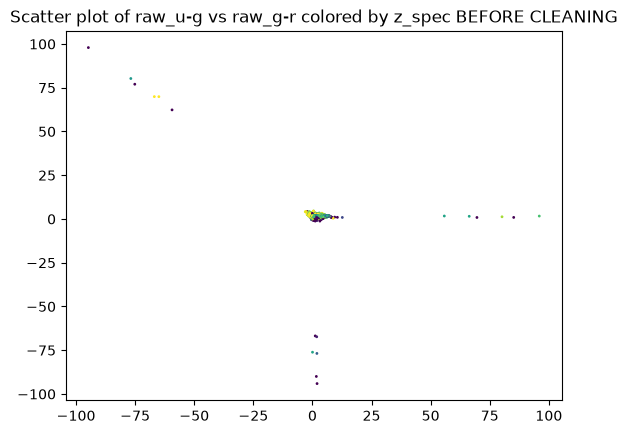

In [7]:
plt.title("Scatter plot of raw_u-g vs raw_g-r colored by z_spec BEFORE CLEANING")
plt.scatter(train_df['raw_u-g'], train_df['raw_g-r'], 
            c=train_df['z_spec'], 
            cmap='viridis', 
            s=1,
            vmin = 0.2,
            vmax = 0.7)
plt.show()

In [8]:
# CLEANING HINT
# Note this is not complete cleaning, but a starting point. 
# Improve on this baseline based on your observations.

# Remove extreme values from u-g color
mask = (
    train_df["raw_u-g"].between(-2, 13)
    & train_df["raw_g-r"].between(-2, 6)
)

train_df = (
    train_df.loc[mask]
    .dropna(subset=["z_spec"])
    .reset_index(drop=True)
)

# TODO:
# - What about raw_r-i and raw_i-z?
# - What about redshifts outside the catalogue range?
# - Should the same cuts be used for corrected colours?

# Drop rows with NaN values in the 'z_spec' column
train_df = train_df.dropna(subset=['z_spec']).reset_index(drop=True)

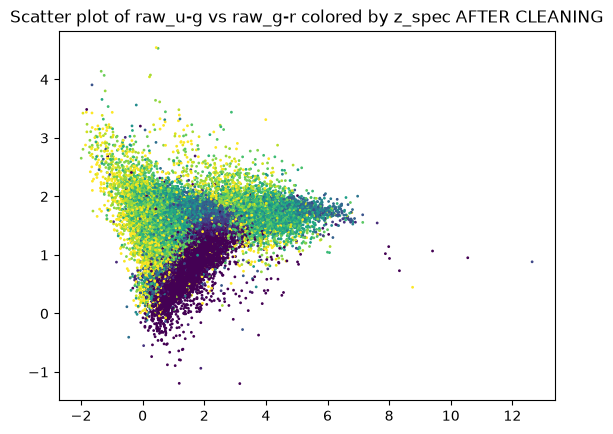

In [9]:
plt.title("Scatter plot of raw_u-g vs raw_g-r colored by z_spec AFTER CLEANING")
plt.scatter(train_df['raw_u-g'], train_df['raw_g-r'], 
            c=train_df['z_spec'], 
            cmap='viridis', 
            s=1,
            vmin = 0.2,
            vmax = 0.7)
plt.show()

In [10]:
print("Training data quality report AFTER CLEANING:")
data.print_quality_report(train_df)

print("Validation data quality report:")
data.print_quality_report(valid_df)

Training data quality report AFTER CLEANING:
                 count  missing  unique    mean     std     min       p01  median     p99    max
source_id        63410        0   63410   50140   28815       3    1013.4   50210   98981  99999
raw_u-g          63410        0   58517  1.6397 0.99101  -1.994  -0.41716  1.6108  5.0355 12.641
raw_g-r          63410        0   56285  1.2177 0.48857 -1.1981   0.24264  1.1663  2.3219 4.5442
raw_r-i          63410        0   50474 0.62055 0.85738 -89.414   0.13988 0.52907  1.3286 2.7882
raw_i-z          63410        0   43807 0.36123  1.1161 -97.474 -0.088645 0.35631 0.77903  89.96
u-g              63410        0   63401  1.6086 0.99103 -2.0079  -0.44733  1.5786  5.0057 12.632
g-r              63410        0   63403  1.1839 0.48978 -1.2402   0.20967  1.1288  2.2884 4.5261
r-i              63410        0   63394 0.60103 0.85766 -89.435   0.11828 0.50645   1.308 2.7616
i-z              63410        0   63393 0.34677  1.1161 -97.481  -0.10525 0.34187 

# Feature engineering

We saw in Lecture 2 that network performance depends strongly on what we give it as input. Both what quantities we input and how we pre-process them are therefore key for good performance. In particular, providing more informative input and pre-processing it can make the task easier for the NN to learn.

TODO: Default features are: 

FEATURES = [
    "raw_u-g",
    "raw_g-r",
    "raw_r-i",
    "raw_i-z",
]

How can we improve on this? 

Is there perhaps any more information we can pass to the network?

### Why `r_mag` may help

Four adjacent colours contain differences between five magnitudes. They therefore discard one degree of freedom: the overall brightness level.

For example, these two objects have identical colours: $(20,19,18,17,16)$ and $(23,22,21,20,19)$, but the second is three magnitudes fainter in every filter. Adding `r_mag` restores some of that missing brightness information.

That does not guarantee it will improve the model. It may encode a mixture of useful redshift information, intrinsic luminosity, and survey-selection effects.

### Why `concentration_r` may help

Two galaxies can have similar broad-band colours but different structures. `concentration_r` gives the network one crude piece of morphological information: $C_r=\frac{R_{90,r}}{R_{50,r}}$.

A centrally concentrated galaxy needs a relatively large radius to move from enclosing 50% to enclosing 90% of its light, producing a larger $C_r$. It is dimensionless and not the physical size of the galaxy.


After choosing our input, let's apply some simple pre-processing to the data:
- Standardize: subtract the training-set mean and divide by the training-set standard deviation.
- TODO: Improve the pre-processing step

In [11]:
# basic pre-processing
for feature in FEATURES:
    mean = train_df[feature].mean()
    std = train_df[feature].std()
    train_df[feature] = (train_df[feature] - mean) / std
    valid_df[feature] = (valid_df[feature] - mean) / std
    test_df[feature] = (test_df[feature] - mean) / std

In [12]:
# create data loaders
train_loader = data.create_data_loader(train_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = data.create_data_loader(valid_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.create_data_loader(test_df, feature_columns=FEATURES, batch_size=BATCH_SIZE, shuffle=False)

# Build and train network

In [13]:
mlp = models.MLPRegressor(
    n_features=len(FEATURES),
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
)

In [14]:
mlp_history = training.train_model(
    mlp,
    train_loader,
    valid_loader,
    loss_fn=lambda prediction, target: F.mse_loss(
        prediction,
        target,
    ),
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    patience=PATIENCE,
)

epoch 01/15 | train=37.65837 | valid=0.14637
epoch 02/15 | train=37.43087 | valid=0.20777
epoch 03/15 | train=37.33461 | valid=0.25903
epoch 04/15 | train=37.29660 | valid=0.30785
epoch 05/15 | train=37.28816 | valid=0.29278
early stopping after epoch 5


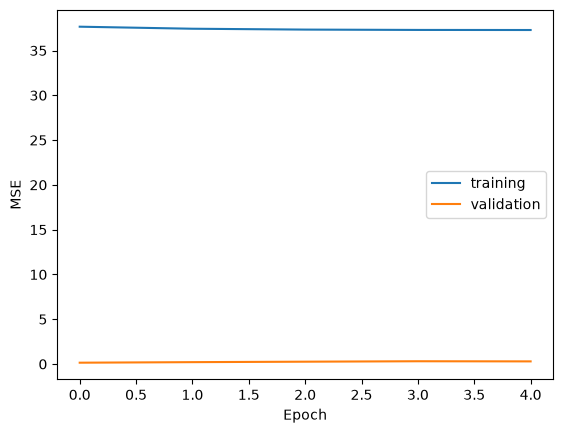

In [15]:
plt.plot(
    mlp_history["train_loss"],
    label="training",
)
plt.plot(
    mlp_history["valid_loss"],
    label="validation",
)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Basic Kaggle submission

Kaggle submission format is csv file with following format:

`source_id, a_1, mu_1, sigma_1, ..., a_5, mu_5, sigma_5`


In [16]:
mlp_submission = submission.submission_from_point_model(
    mlp,
    test_loader,
    valid_loader,
    output_path="submissions/mlp_baseline.csv",
)

mlp_submission.head()

validation residual sigma = 0.382584
wrote submissions/mlp_baseline.csv with shape (20000, 16)


,source_id,a_1,mu_1,sigma_1,a_2,mu_2,sigma_2,a_3,mu_3,sigma_3,a_4,mu_4,sigma_4,a_5,mu_5,sigma_5
0,2,1.0,0.409118,0.382584,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,5,1.0,0.548846,0.382584,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,15,1.0,0.572993,0.382584,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,18,1.0,0.519237,0.382584,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,20,1.0,0.402263,0.382584,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


# MDN Model

In [17]:
mdn = models.MDN(
    n_features=len(FEATURES),
    hidden_dims=HIDDEN_DIMS,
    n_components=N_COMPONENTS,
    dropout=DROPOUT,
)

In [18]:
mdn_history = training.train_model(
    mdn,
    train_loader,
    valid_loader,
    loss_fn=models.mdn_nll,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    patience=PATIENCE,
)

epoch 01/15 | train=20.74269 | valid=0.37862
epoch 02/15 | train=12.37196 | valid=-0.05627
epoch 03/15 | train=7.83097 | valid=-0.43904
epoch 04/15 | train=5.07703 | valid=-0.70712
epoch 05/15 | train=3.28511 | valid=-0.98833
epoch 06/15 | train=2.02771 | valid=-1.23935
epoch 07/15 | train=1.13250 | valid=-1.40857
epoch 08/15 | train=0.54823 | valid=-1.47318
epoch 09/15 | train=0.15567 | valid=-1.50032
epoch 10/15 | train=-0.13314 | valid=-1.51859
epoch 11/15 | train=-0.33049 | valid=-1.53258
epoch 12/15 | train=-0.49309 | valid=-1.55102
epoch 13/15 | train=-0.61751 | valid=-1.56350
epoch 14/15 | train=-0.72261 | valid=-1.58832
epoch 15/15 | train=-0.81082 | valid=-1.60153


# Validate the models

Training loss tells us how well the model fits the examples used to
update its weights. Validation loss tells us how well it **generalises**
to examples that were not used for those updates.

For the deterministic MLP, we compare its point predictions with the
true redshifts using RMSE.

For the MDN, we can also consider:

1. validation negative log likelihood
2. the accuracy of its predictive mean
3. the shapes of several individual predicted PDFs

A single numerical score is not enough to fully validate a
probabilistic model, but these checks provide a useful starting point.

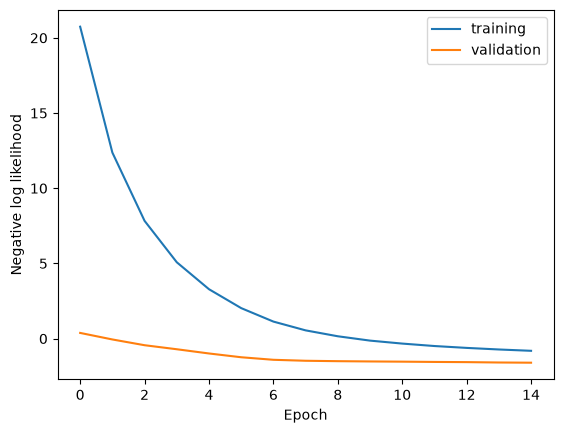

In [19]:
plt.plot(
    mdn_history["train_loss"],
    label="training",
)

plt.plot(
    mdn_history["valid_loss"],
    label="validation",
)

plt.xlabel("Epoch")
plt.ylabel("Negative log likelihood")
plt.legend()
plt.show()

A continuous probability density may be larger than one, so its negative log likelihood can be negative. Lower values are still better.

In [20]:
device = next(mdn.parameters()).device
mlp.to(device)
mdn.to(device)

true_redshifts = []
mlp_predictions = []
mdn_predictions = []

mdn_nll_sum = 0.0
n_valid = 0

mlp.eval()
mdn.eval()

with torch.no_grad():
    for features, targets, _source_ids in valid_loader:
        features = features.to(device)
        targets = targets.to(device)

        # Point prediction
        point_prediction = mlp(features)

        # Probabilistic prediction
        weights, means, sigmas = mdn(features)
        mixture_mean = torch.sum(
            weights * means,
            dim=1,
        )

        true_redshifts.append(
            targets.cpu().numpy()
        )
        mlp_predictions.append(
            point_prediction.cpu().numpy()
        )
        mdn_predictions.append(
            mixture_mean.cpu().numpy()
        )

        batch_nll = models.mdn_nll(
            (weights, means, sigmas),
            targets,
        )

        mdn_nll_sum += (
            batch_nll.item() * len(targets)
        )
        n_valid += len(targets)

true_redshifts = np.concatenate(
    true_redshifts
)

mlp_predictions = np.concatenate(
    mlp_predictions
)

mdn_predictions = np.concatenate(
    mdn_predictions
)

mlp_rmse = np.sqrt(
    np.mean(
        (mlp_predictions - true_redshifts) ** 2
    )
)

mdn_rmse = np.sqrt(
    np.mean(
        (mdn_predictions - true_redshifts) ** 2
    )
)

mdn_nll = mdn_nll_sum / n_valid

print(f"MLP validation RMSE: {mlp_rmse:.4f}")
print(f"MDN mean validation RMSE: {mdn_rmse:.4f}")
print(f"MDN validation NLL: {mdn_nll:.4f}")

MLP validation RMSE: 0.3826
MDN mean validation RMSE: 0.1250
MDN validation NLL: -1.6015


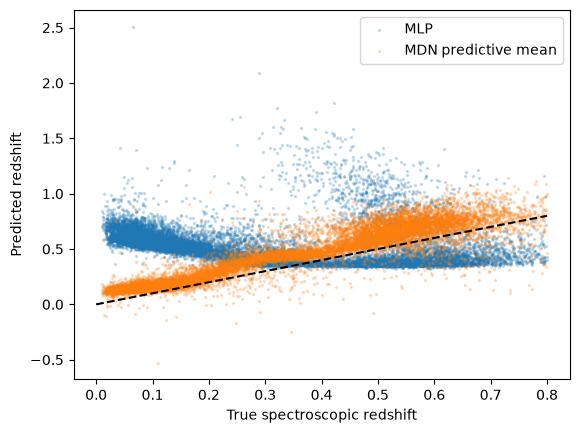

In [21]:
plt.scatter(
    true_redshifts,
    mlp_predictions,
    s=2,
    alpha=0.2,
    label="MLP",
)

plt.scatter(
    true_redshifts,
    mdn_predictions,
    s=2,
    alpha=0.2,
    label="MDN predictive mean",
)

plt.plot(
    [0.0, 0.8],
    [0.0, 0.8],
    "k--",
)

plt.xlabel("True spectroscopic redshift")
plt.ylabel("Predicted redshift")
plt.legend()
plt.show()

## Inspect MDN PDFs

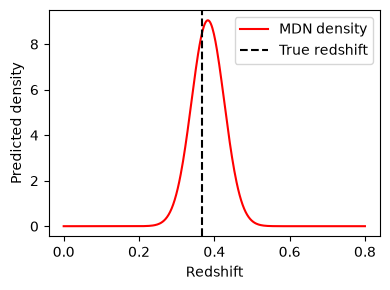

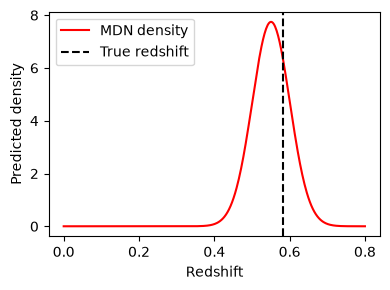

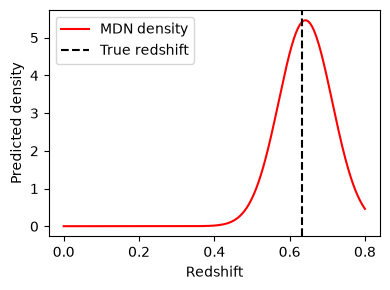

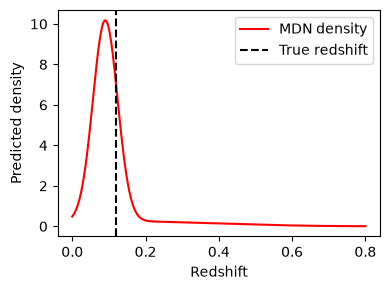

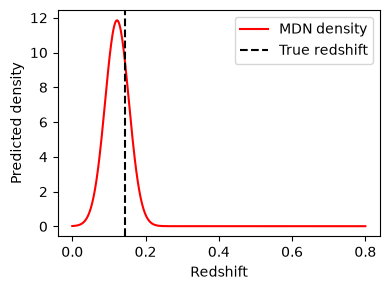

In [22]:
features, targets, _source_ids = next(iter(valid_loader))

features = features.to(device)

with torch.no_grad():
    weights, means, sigmas = mdn(features)

z_grid = torch.linspace(0.0, 0.8, 400, device=device)

N = 5

for index in range(N):
    component_distributions = (
        torch.distributions.Normal(means[index], sigmas[index],))

    component_pdfs = torch.exp(component_distributions.log_prob(z_grid[:, None]))

    mixture_pdf = torch.sum(weights[index] * component_pdfs,dim=1)
    fig, ax = plt.subplots(1,1,figsize=(4, 3))
    ax.plot(z_grid.cpu(),mixture_pdf.cpu(), color = "r", label="MDN density")

    ax.axvline(targets[index].item(), linestyle="--", label="True redshift", color = "k")

    ax.set_xlabel("Redshift")
    ax.legend()

    ax.set_ylabel("Predicted density")
    plt.tight_layout()
    plt.show()

## MDN submission

In [23]:
mdn_submission = submission.submission_from_prob_model(
    mdn,
    test_loader,
    output_path="submissions/mdn_baseline.csv",
)

mdn_submission.head()

wrote submissions/mdn_baseline.csv with shape (20000, 16)


,source_id,a_1,mu_1,sigma_1,a_2,mu_2,sigma_2,a_3,mu_3,sigma_3,a_4,mu_4,sigma_4,a_5,mu_5,sigma_5
0,2,0.015071,1.203470,2.365448,0.963647,0.464571,0.053344,0.021282,5.824278,4.175170,0.0,0.0,1.0,0.0,0.0,1.0
1,5,0.014073,0.846206,1.786484,0.969658,0.185054,0.039171,0.016268,5.357633,4.094403,0.0,0.0,1.0,0.0,0.0,1.0
2,15,0.162096,0.284852,0.270979,0.827950,0.124123,0.043743,0.009954,7.653158,6.318557,0.0,0.0,1.0,0.0,0.0,1.0
3,18,0.054593,0.232046,0.503914,0.934449,0.110911,0.034220,0.010958,6.109932,5.096665,0.0,0.0,1.0,0.0,0.0,1.0
4,20,0.011209,0.914078,1.885876,0.976555,0.302774,0.038821,0.012236,5.418743,4.091166,0.0,0.0,1.0,0.0,0.0,1.0


# TODO: tune the models

Suggestions:
- Vary hidden layer number
- Vary number of neurons
- Vary number of components K=1,2,3,5
- Vary the dropout fraction
- Vary the initial learning rate
- Vary the number of epochs
- Vary the early stopping patience
- Vary pre-processing steps

I suggest changing one thing at a time so you actually know what improves performance and what doesn't.
Keep careful track of changes and performance, for example, using this kind of table:

| Model | Features | Cleaning | K | Validation RMSE | Validation NLL | Runtime |
| ----- | -------- | -------- | --: | --------------: | -------------: | ------: |


# Final submission

Choose your best file from the `submissions/` directory and upload it
to the Kaggle competition.

Before uploading, check:

- the file has 20,000 rows
- `source_id` is the first column
- every source ID occurs exactly once
- all weights are non-negative and sum to one
- every `sigma` is positive
- there are no `NaN` or infinite values

Suggested Kaggle submission description:

    team=Orion | model=MDN K=3 64x64 |
    features=corrected colours+r_mag |
    cleaning=colour+target cuts

## Optional extension: uncertainty in the spectroscopic target

To work on this extension, add `"z_spec_err"` to the list passed to
`data.load_data`. Do not add it to `FEATURES`: it is label metadata,
not a photometric model input.

This quantity is **not an input feature**. A galaxy with only photometric observations would not have either `z_spec` or `z_spec_err`. Instead, `z_spec_err` describes uncertainty in the supervised-learning label.

The notebook ignores this uncertainty and treats `z_spec` as the target value. But there are some more advanced ways to use it.

### 1. Data-quality check

Rule 0 from Lecture 2 still applies! Inspect the distribution of `z_spec_err`. Missing, negative, or unusually large values may identify unreliable labels that should be removed or treated separately.

### 2. Compare spectroscopic and photometric uncertainty

The MDN predicts a redshift distribution. For a Gaussian mixture, its predictive mean is
$$\bar z = \sum_k a_k\mu_k,$$

and its total predictive variance is

$$\sigma_{\rm pred}^2 = \sum_k a_k\left(\sigma_k^2+\mu_k^2\right) -\bar z^2.$$

This total mixture uncertainty can be compared with `z_spec_err`.

We normally expect the uncertainty inferred from five-band photometry to be much larger than the spectroscopic measurement uncertainty. However, this is a qualitative diagnostic rather than a strict per-object rule. In particular, an individual mixture-component width is not the same as the total uncertainty of a multimodal mixture.

### 3. Include label uncertainty in the loss

Suppose the MDN predicts the distribution of the underlying redshift,

$$ p_\phi(z\mid\mathbf{x}) = \sum_k a_k\, \mathcal N(z\mid\mu_k,\sigma_k^2).$$


If the measured spectroscopic redshift has Gaussian uncertainty $\sigma_{{\rm spec},i}$, the likelihood of the observed label becomes

$$ p_\phi(z_{{\rm spec},i}\mid\mathbf{x}_i) = \sum_k a_{ik}\, \mathcal N\left( z_{{\rm spec},i} \mid \mu_{ik}, \sigma_{ik}^2+\sigma_{{\rm spec},i}^2\right).$$

Thus, the spectroscopic uncertainty can be included by adding it in quadrature to every predicted component width during training:

$$\sigma_{{\rm total},ik} = \sqrt{ \sigma_{ik}^2+ \sigma_{{\rm spec},i}^2}.$$

This is an optional advanced task and is not required for a valid Kaggle submission.